### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 20/20 [00:19<00:00,  1.05it/s]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038349,2026-03-24 13:59:35,70024.500000,70030.898438,70016.398438,70024.898438,2.631,0.132,0.106,0.026,0.606061,...,0.564,0.015,0.035,0.010,0.021,0.002,0.002,0.007,0.059,0.003
1038350,2026-03-24 13:59:40,70024.000000,70026.796875,70016.398438,70021.898438,1.838,0.358,0.000,0.358,-1.000000,...,0.207,0.008,3.762,0.076,0.002,0.031,0.020,0.002,0.034,0.056
1038351,2026-03-24 13:59:45,70030.000000,70039.000000,70021.101562,70033.101562,6.931,0.214,0.133,0.081,0.242991,...,0.003,0.002,0.142,0.006,0.006,0.015,0.565,0.020,0.003,0.007
1038352,2026-03-24 13:59:50,70047.898438,70047.898438,70037.101562,70043.398438,0.548,0.000,0.000,0.000,0.000000,...,0.859,0.002,0.004,0.002,0.002,0.020,0.007,0.114,0.002,0.011


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 1038353/1038353 [00:09<00:00, 111125.06it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,1.591322e-04,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.148349,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,2.141049e-04,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.140864,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,2.752305e-04,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.140864,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,4.429674e-04,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.137164,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,9.560574e-04,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.144695,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038349,17.550000,2.282031,33.555460,31.671013,1.019638e-11,17.549975,0.671945,-0.298789,-0.083055,-32.327368,...,1.057757,0.884948,-2.632827,-0.080934,-0.063516,70016.398438,70030.898438,70024.898438,-0.000047,0.000148
1038350,15.709896,0.933477,32.783560,30.275832,1.156815e-11,15.709873,0.400031,-0.202791,-0.107494,-5.776654,...,1.027778,0.737240,-0.669247,-0.320383,-0.340132,70016.398438,70026.796875,70021.898438,0.000116,0.000256
1038351,15.936589,0.457305,32.287389,29.309447,2.397512e-12,15.936566,0.188500,0.420613,0.179574,12.111731,...,0.915118,1.959193,1.207319,0.303746,0.343944,70021.101562,70039.000000,70033.101562,0.000134,0.000154
1038352,16.666667,0.026531,31.704372,28.300686,4.586850e-11,16.666643,0.194086,3.710658,1.899683,46.328101,...,0.904182,2.760659,5.158571,0.744088,0.748565,70037.101562,70047.898438,70043.398438,0.000166,0.000204


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=13,
)

Обучение модели...
[0]	validation_0-rmse:0.00018
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00016
[200]	validation_0-rmse:0.00016
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[649]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_mid.json


MAE                      : 0.000094
RMSE                     : 0.000154
R²                       : 0.279016
MAE / mean|Δ|            : 0.816673
RMSE / RMSE_base         : 0.849094
mean|Δ| (target)         : 0.000115

------------------------------------------------------------
Directional Accuracy     : 0.637716
Target Pos Ratio         : 0.473440
Profit Factor            : 1.682700
Avg Gain (correct)       : -0.000004
Avg Loss (incorrect)     : 0.000004

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6359, 0.6395)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000123, 0.00161]    0.000224         0.923415    -0.000006      25958
(6.65e-05, 0.000123]    0.000090         0.819593    -0.000003      25958
(4.22e-05, 6.65e-05]    0.000053         0.740658    -0.000002      25958


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


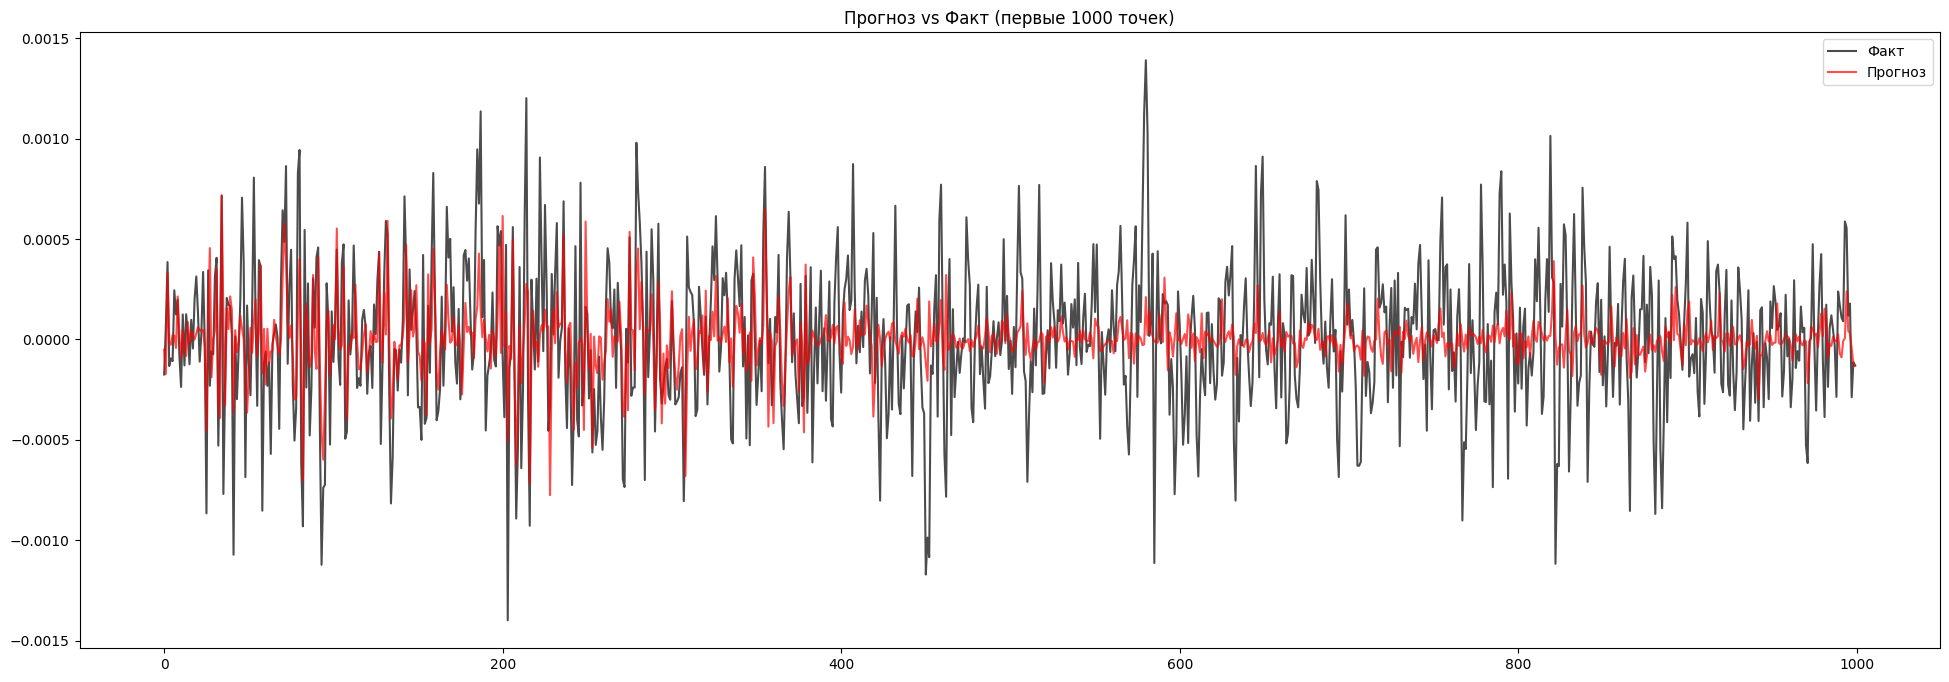

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=8,
)

Обучение модели...
[0]	validation_0-rmse:0.00020
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00015
[200]	validation_0-rmse:0.00015
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[650]	validation_0-rmse:0.00015
[700]	validation_0-rmse:0.00015
[750]	validation_0-rmse:0.00015
[800]	validation_0-rmse:0.00015
[850]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000100
RMSE                     : 0.000151
R²                       : 0.418966
MAE / mean|Δ|            : 0.592469
RMSE / RMSE_base         : 0.579129
mean|Δ| (target)         : 0.000169

------------------------------------------------------------
Directional Accuracy     : 0.892419
Target Pos Ratio         : 0.892419
Profit Factor            : 43977953524.217590
Avg Gain (correct)       : 0.000190
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.8913, 0.8936)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
  (0.000334, 0.0031]    0.000462         0.999807     0.000457      25958
(0.000242, 0.000334]    0.000283         0.996263     0.000281      25958
(0.000196, 0.000242]    0.000218         0.984282     0.000212    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


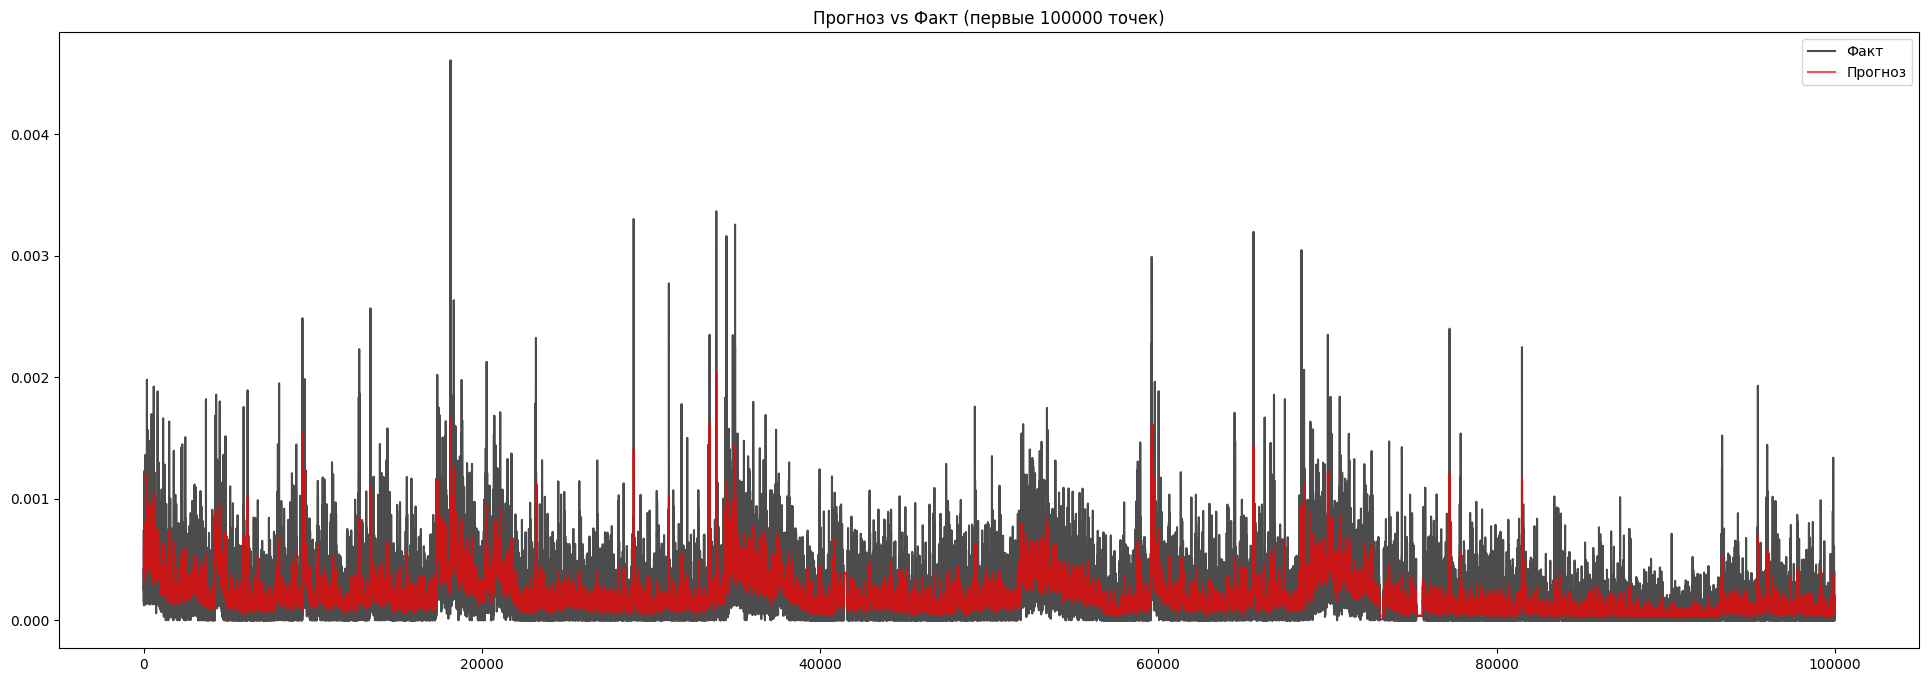

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)